# RUL-Turbine: 02_baseline_model.ipynb — Classical ML Baseline

This notebook builds classical machine learning baselines for Remaining Useful Life (RUL) prediction on the NASA C-MAPSS FD001 dataset.

## Methodology
1. **Preprocessing**: Load raw data, cap RUL at 125, drop the 7 flat sensors, and min-max scale.
2. **Feature Engineering**: For each sliding window of size 30, extract:
   - Rolling **mean** of the 14 sensors.
   - Rolling **standard deviation (std)** of the 14 sensors.
   - Rolling **slope (trend)** of the 14 sensors.
   - This yields a 42-dimensional feature vector per window sample.
3. **Modeling**: Train and evaluate:
   - **Linear Regression** (simplest linear baseline)
   - **Random Forest Regressor** (non-linear ensemble baseline)
   - **XGBoost Regressor** (gradient-boosted baseline)
4. **Evaluation**: Compare models using Root Mean Squared Error (RMSE) and the **PHM08 Asymmetric Score** (which penalizes late predictions more heavily).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Append src directory to path
sys.path.append(os.path.abspath('../src'))
from utils import preprocess_data_and_save_npy, extract_rolling_features, compute_phm08_score, KEEP_SENSORS

# Configure plotting styles
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
sns.set_palette('muted')

print("Libraries imported and settings configured.")

Libraries imported and settings configured.


## 1. Load Preprocessed Sliding Windows & Engineer Features

We call `preprocess_data_and_save_npy` to prepare the sliding window data (`X_train` has shape `(17731, 30, 14)`), then extract rolling features using our helper function.

In [2]:
# Run preprocessing (this outputs X_train, y_train, X_test, y_test as .npy files)
X_train, y_train, X_test, y_test = preprocess_data_and_save_npy(
    subset='FD001', 
    raw_dir='../data/raw', 
    processed_dir='../data/processed',
    window_size=30,
    cap=125
)

# Extract rolling features
X_train_feat = extract_rolling_features(X_train)
X_test_feat = extract_rolling_features(X_test)

print(f"X_train_feat shape: {X_train_feat.shape} (17731 samples, 42 features)")
print(f"X_test_feat shape: {X_test_feat.shape} (100 test engine final windows, 42 features)")

# Generate feature names list for plots
feature_names = []
for stat in ['mean', 'std', 'slope']:
    for s in KEEP_SENSORS:
        feature_names.append(f"{s.upper()}_{stat}")
feature_names = np.array(feature_names)

Processed dataset saved successfully to ../data/processed:
  X_train: (17731, 30, 14)
  y_train: (17731,)
  X_test: (100, 30, 14)
  y_test: (100,)
X_train_feat shape: (17731, 42) (17731 samples, 42 features)
X_test_feat shape: (100, 42) (100 test engine final windows, 42 features)


## 2. Model 1: Linear Regression Baseline

We train a simple ordinary least squares linear regression model. Predictions are clipped below at 0 (since RUL cannot be negative).

In [3]:
lr_model = LinearRegression()
lr_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
lr_pred_train = np.clip(lr_model.predict(X_train_feat), 0, None)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, lr_pred_train))

# Predict and evaluate on test set
lr_pred_test = np.clip(lr_model.predict(X_test_feat), 0, None)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_score_test = compute_phm08_score(y_test, lr_pred_test)

print("Linear Regression Results:")
print(f"  Train RMSE: {lr_rmse_train:.2f}")
print(f"  Test RMSE: {lr_rmse_test:.2f}")
print(f"  Test PHM08 Score: {lr_score_test:.2f}")

Linear Regression Results:
  Train RMSE: 15.64
  Test RMSE: 16.29
  Test PHM08 Score: 440.77


## 3. Model 2: Random Forest Regressor Baseline

We train a Random Forest ensemble model. We restrict the depth slightly (`max_depth=12`) to prevent overfitting.

In [4]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
rf_pred_train = np.clip(rf_model.predict(X_train_feat), 0, None)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_pred_train))

# Predict and evaluate on test set
rf_pred_test = np.clip(rf_model.predict(X_test_feat), 0, None)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_score_test = compute_phm08_score(y_test, rf_pred_test)

print("Random Forest Results:")
print(f"  Train RMSE: {rf_rmse_train:.2f}")
print(f"  Test RMSE: {rf_rmse_test:.2f}")
print(f"  Test PHM08 Score: {rf_score_test:.2f}")

Random Forest Results:
  Train RMSE: 7.04
  Test RMSE: 13.53
  Test PHM08 Score: 266.48


## 4. Model 3: XGBoost Regressor Baseline

We train an XGBoost gradient-boosted decision tree regressor. We configure reasonable hyperparameters.

In [5]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
xgb_pred_train = np.clip(xgb_model.predict(X_train_feat), 0, None)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_pred_train))

# Predict and evaluate on test set
xgb_pred_test = np.clip(xgb_model.predict(X_test_feat), 0, None)
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_score_test = compute_phm08_score(y_test, xgb_pred_test)

print("XGBoost Results:")
print(f"  Train RMSE: {xgb_rmse_train:.2f}")
print(f"  Test RMSE: {xgb_rmse_test:.2f}")
print(f"  Test PHM08 Score: {xgb_score_test:.2f}")

XGBoost Results:
  Train RMSE: 9.18
  Test RMSE: 13.29
  Test PHM08 Score: 249.40


## 5. Summary Table

Let's compare the performance of all 3 classical baseline models in a single table.

In [6]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train RMSE': [lr_rmse_train, rf_rmse_train, xgb_rmse_train],
    'Test RMSE': [lr_rmse_test, rf_rmse_test, xgb_rmse_test],
    'Test PHM08 Score': [lr_score_test, rf_score_test, xgb_score_test]
})

# Format table for clear presentation
results_df.round(2).style.highlight_min(subset=['Test RMSE', 'Test PHM08 Score'], color='#e2f0d9')

,Model,Train RMSE,Test RMSE,Test PHM08 Score
0,Linear Regression,15.640000,16.290000,440.770000
1,Random Forest,7.040000,13.530000,266.480000
2,XGBoost,9.180000,13.290000,249.400000


## 6. Feature Importance Visualization

Let's examine which rolling features contribute most to the predictions. We will plot the top 15 features by importance for both Random Forest and XGBoost.

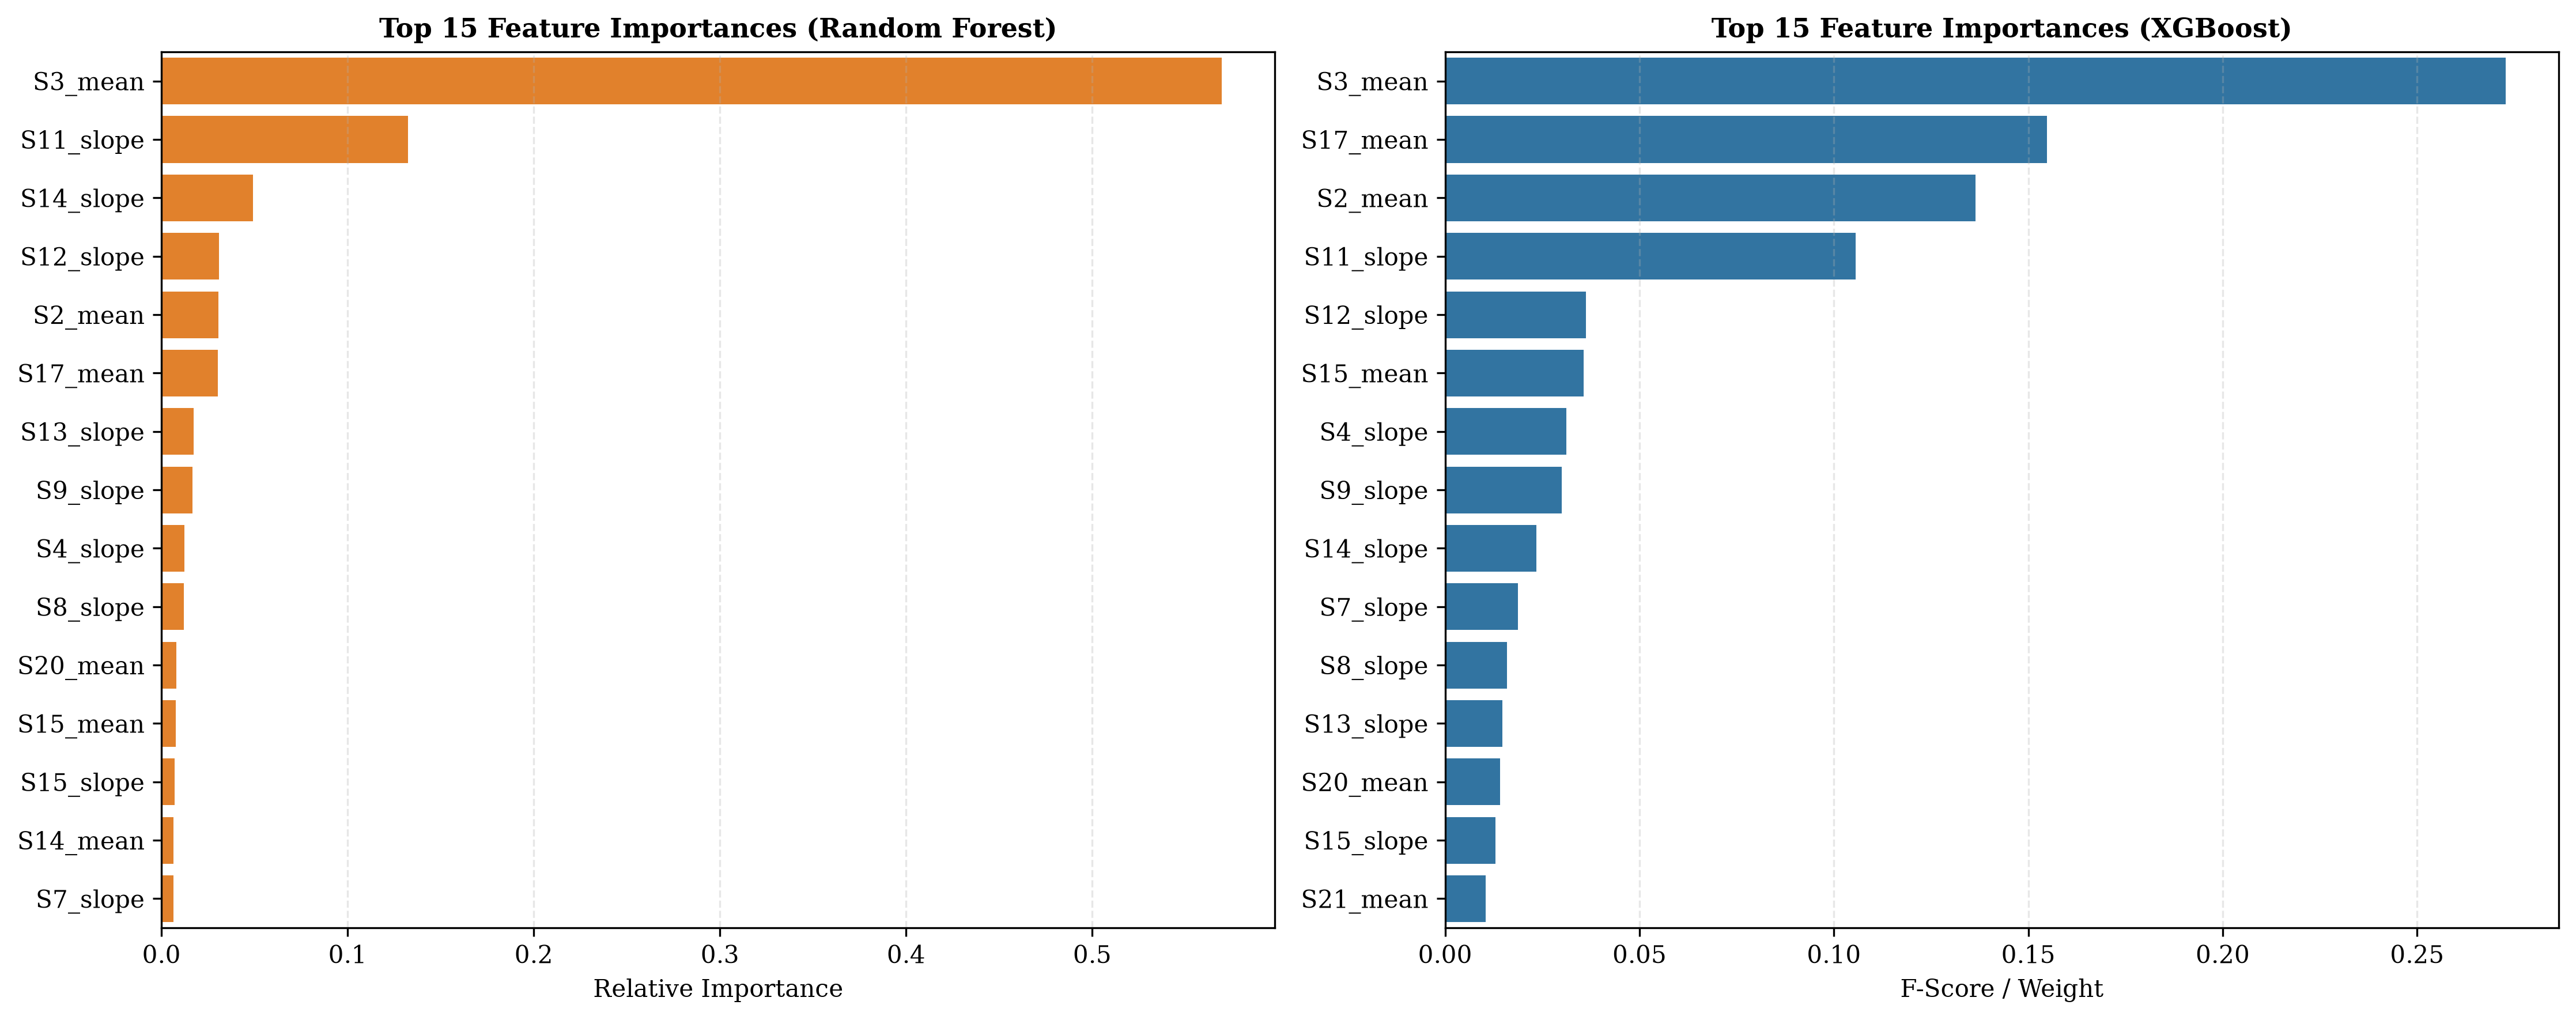

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

# Random Forest Importances
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1][:15]

sns.barplot(x=rf_importances[rf_indices], y=feature_names[rf_indices], ax=axs[0], color='#ff7f0e')
axs[0].set_title('Top 15 Feature Importances (Random Forest)', fontsize=11, fontweight='bold')
axs[0].set_xlabel('Relative Importance')

# XGBoost Importances
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1][:15]

sns.barplot(x=xgb_importances[xgb_indices], y=feature_names[xgb_indices], ax=axs[1], color='#1f77b4')
axs[1].set_title('Top 15 Feature Importances (XGBoost)', fontsize=11, fontweight='bold')
axs[1].set_xlabel('F-Score / Weight')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/baseline_feature_importances.png')
plt.show()

### Observations
- **Crucial Sensors**: Sensor channels `s11` (Throttle pressure at HPC outlet), `s4` (Total temperature at LPT outlet), `s12` (Ratio of fuel flow to Ps30) and `s15` (Bypass ratio) feature prominently in the top importances.
- **Crucial Statistics**: The rolling **mean** and rolling **slope** are highly important, which makes intuitive physical sense as they capture the current health degradation state and the degradation rate/trend of the turbofan engine.

In the next notebook (**03_deep_model.ipynb**), we will build a deep LSTM sequence model that learns directly from the raw sequence of these 14 sensors without manual rolling feature engineering.